# Dataset Statistics & Training Readiness

Aggregate checks across all episodes: duration distributions, per-channel stats,
action distributions, temporal diversity, channel correlations, and outlier detection.
Run this once your dataset is collected to decide if it's ready for training.

In [1]:
import numpy as np
import h5py
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True

In [2]:
REPO_ROOT = Path().resolve().parent
DATASET_DIR = REPO_ROOT / "dataset"

datasets = sorted([d for d in DATASET_DIR.iterdir() if d.is_dir() and (d / "dataset_index.yaml").exists()])
DATA_DIR = datasets[-1]
print(f"Using: {DATA_DIR.name}")

with open(DATA_DIR / "dataset_index.yaml", "r") as f:
    index = yaml.safe_load(f)

successful = [e for e in index if e["success"]]
failed = [e for e in index if not e["success"]]
print(f"Total: {len(index)} | Success: {len(successful)} ({100*len(successful)/len(index):.1f}%) | Failed: {len(failed)}")

Using: rect_small_tight_200Hz_2026-03-29
Total: 978 | Success: 646 (66.1%) | Failed: 332


In [3]:
def load_episode(path):
    data = {}
    with h5py.File(path, 'r') as f:
        for group in f.keys():
            if isinstance(f[group], h5py.Group):
                for k in f[group].keys():
                    data[f'{group}/{k}'] = f[group][k][()]
    return data

## 1. Episode Duration Distribution
Histogram colored by success/fail. Look for:
- Are successful episodes clustered in a clean range?
- Is there a long tail of barely-succeeded episodes (borderline cases that may teach bad habits)?
- Where do failures pile up (timeout boundary = max duration)?

Successful episodes — mean: 24.0s, median: 21.5s, min: 6.9s, max: 57.5s


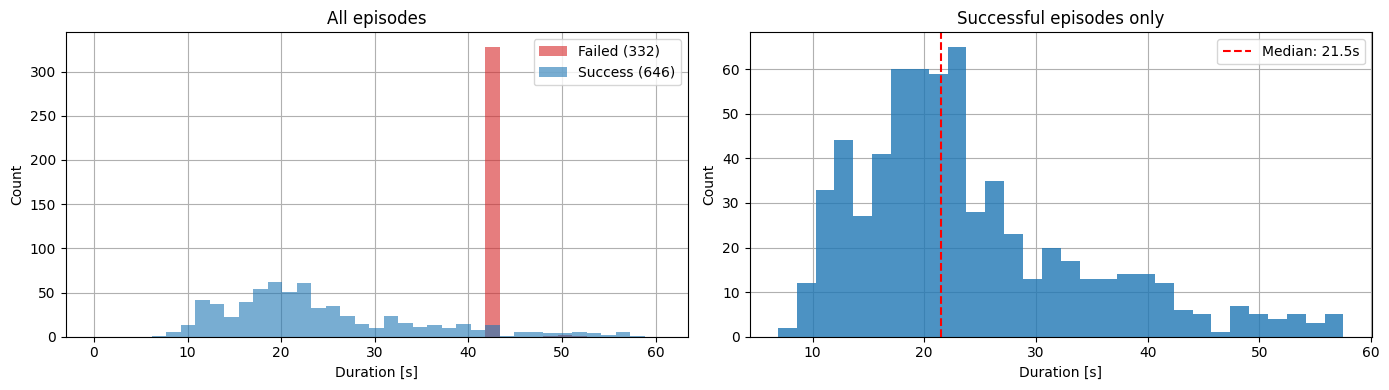

In [4]:
dur_success = [e['duration'] for e in successful]
dur_failed = [e['duration'] for e in failed]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bins = np.linspace(0, max(dur_success + dur_failed) * 1.05, 40)
axes[0].hist(dur_failed, bins=bins, alpha=0.6, label=f'Failed ({len(failed)})', color='C3')
axes[0].hist(dur_success, bins=bins, alpha=0.6, label=f'Success ({len(successful)})', color='C0')
axes[0].set_xlabel('Duration [s]')
axes[0].set_ylabel('Count')
axes[0].set_title('All episodes')
axes[0].legend()

axes[1].hist(dur_success, bins=30, alpha=0.8, color='C0')
axes[1].axvline(np.median(dur_success), color='red', linestyle='--', label=f'Median: {np.median(dur_success):.1f}s')
axes[1].set_xlabel('Duration [s]')
axes[1].set_ylabel('Count')
axes[1].set_title('Successful episodes only')
axes[1].legend()

plt.tight_layout()

print(f'Successful episodes — mean: {np.mean(dur_success):.1f}s, median: {np.median(dur_success):.1f}s, '
      f'min: {np.min(dur_success):.1f}s, max: {np.max(dur_success):.1f}s')

## 2. Step Count Distribution
Sanity check that step counts match duration * control_freq.
Also catch any suspiciously short episodes (peg fell in by luck).

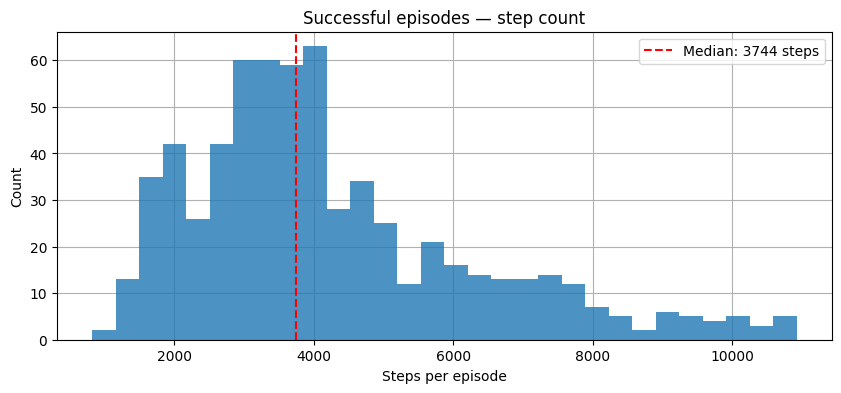

In [5]:
steps_success = [e['n_steps'] for e in successful]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(steps_success, bins=30, alpha=0.8, color='C0')
ax.axvline(np.median(steps_success), color='red', linestyle='--', label=f'Median: {int(np.median(steps_success))} steps')
ax.set_xlabel('Steps per episode')
ax.set_ylabel('Count')
ax.set_title('Successful episodes — step count')
ax.legend()

short_threshold = 200  # episodes shorter than this are suspiciously fast
short_eps = [e for e in successful if e['n_steps'] < short_threshold]
if short_eps:
    print(f'WARNING: {len(short_eps)} episodes with < {short_threshold} steps — inspect these manually')
    for e in short_eps:
        print(f"  Episode {e['episode_id']}: {e['n_steps']} steps, {e['duration']:.1f}s")

## 3. Failure Phase Breakdown
Which phase causes most failures? If SEARCH dominates, the expert's search coverage is the bottleneck, not the insert logic.

  SEARCH: 328 (99%)
  INSERT: 4 (1%)


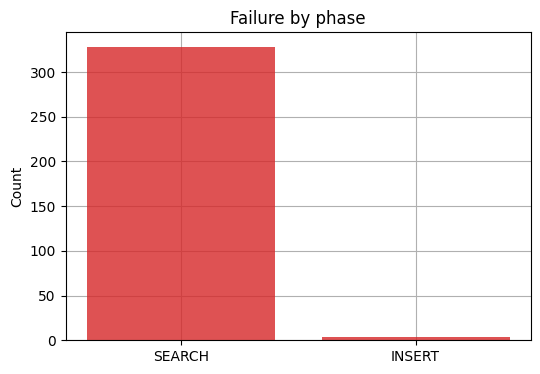

In [6]:
if failed:
    from collections import Counter
    phases = Counter(e.get('fail_phase', 'UNKNOWN') for e in failed)
    
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(phases.keys(), phases.values(), color='C3', alpha=0.8)
    ax.set_ylabel('Count')
    ax.set_title('Failure by phase')
    for phase, count in phases.items():
        print(f'  {phase}: {count} ({100*count/len(failed):.0f}%)')
else:
    print('No failed episodes')

## 4. Load All Successful Episodes
This loads everything into memory. For 600 episodes at ~4000 steps each, that's ~600 * 4000 * 24 floats ≈ 440MB — should be fine.

In [7]:
all_obs = []
all_actions = []
episode_lengths = []

for entry in successful:
    ep = load_episode(DATA_DIR / entry['path'])
    obs = np.concatenate([ep['obs/f_ext'], ep['obs/f_internal'], ep['obs/ee_velocity']], axis=1)
    act = ep['action/Fff']
    all_obs.append(obs)
    all_actions.append(act)
    episode_lengths.append(len(obs))

obs_flat = np.concatenate(all_obs, axis=0)
act_flat = np.concatenate(all_actions, axis=0)

n_obs_dim = obs_flat.shape[1]
print(f'Loaded {len(all_obs)} episodes, {obs_flat.shape[0]} total timesteps')
print(f'Obs dim: {n_obs_dim}, Action dim: {act_flat.shape[1]}')

Loaded 646 episodes, 2729062 total timesteps
Obs dim: 18, Action dim: 6


## 5. Per-Channel Statistics
Box plots of each obs and action channel across all timesteps.
Check for: dead channels (near-zero variance), extreme outliers, channels with wildly different scales.

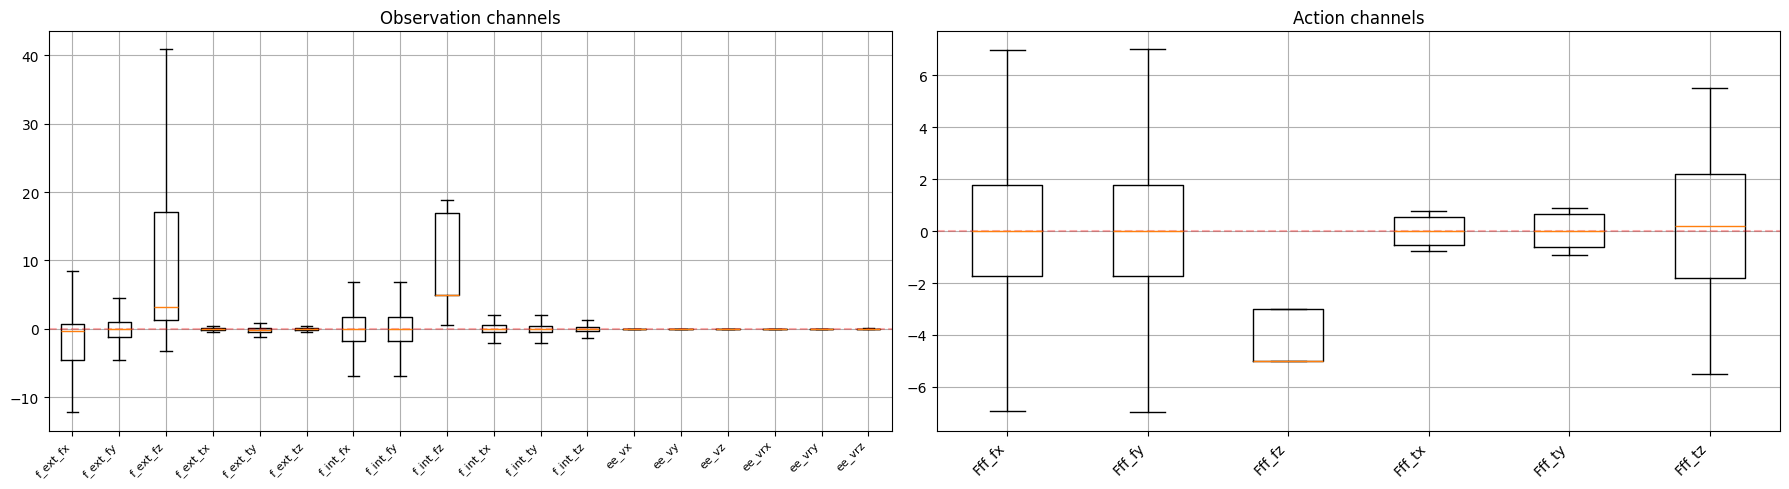

In [8]:
obs_labels = (['f_ext_' + s for s in ['fx','fy','fz','tx','ty','tz']] +
              ['f_int_' + s for s in ['fx','fy','fz','tx','ty','tz']] +
              ['ee_v' + s for s in ['x','y','z','rx','ry','rz']][:obs_flat.shape[1]-12])
act_labels = ['Fff_' + s for s in ['fx','fy','fz','tx','ty','tz']]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

bp1 = axes[0].boxplot([obs_flat[:, i] for i in range(n_obs_dim)], showfliers=False)
axes[0].set_xticklabels(obs_labels, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Observation channels')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.3)

bp2 = axes[1].boxplot([act_flat[:, i] for i in range(6)], showfliers=False)
axes[1].set_xticklabels(act_labels, rotation=45, ha='right')
axes[1].set_title('Action channels')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()

In [9]:
print('Per-channel statistics (obs):')
print(f'{"Channel":<14} {"Mean":>10} {"Std":>10} {"Min":>10} {"Max":>10}')
for i, lbl in enumerate(obs_labels):
    col = obs_flat[:, i]
    print(f'{lbl:<14} {col.mean():>10.4f} {col.std():>10.4f} {col.min():>10.4f} {col.max():>10.4f}')

print(f'\nPer-channel statistics (action):')
print(f'{"Channel":<14} {"Mean":>10} {"Std":>10} {"Min":>10} {"Max":>10}')
for i, lbl in enumerate(act_labels):
    col = act_flat[:, i]
    print(f'{lbl:<14} {col.mean():>10.4f} {col.std():>10.4f} {col.min():>10.4f} {col.max():>10.4f}')

Per-channel statistics (obs):
Channel              Mean        Std        Min        Max
f_ext_fx          -1.2245     5.1467   -24.6046    50.6838
f_ext_fy          -0.0329     2.2829   -37.5198    42.0202
f_ext_fz           7.7683     8.6017    -3.2755    84.6400
f_ext_tx          -0.0528     0.5232    -6.2533     5.1950
f_ext_ty          -0.1268     0.9783    -4.3308     4.3476
f_ext_tz          -0.1121     1.2273   -10.2287     5.8461
f_int_fx          -0.2408     3.1753   -12.6826     9.8557
f_int_fy          -0.0230     3.0595   -11.2053    11.7422
f_int_fz           9.1835     5.8499     0.5186    18.9126
f_int_tx          -0.0088     0.5425    -3.0388     2.9916
f_int_ty          -0.0184     0.5845    -2.2274     2.5213
f_int_tz          -0.1050     1.6199   -12.1821    12.1258
ee_vx             -0.0003     0.0037    -0.0779     0.0403
ee_vy              0.0000     0.0055    -0.0710     0.0685
ee_vz             -0.0028     0.0070    -0.0801     0.0292
ee_vrx             0.0000 

## 6. Action Distributions
Histograms of each Fff channel. Expect:
- XY force: sinusoidal → bimodal-ish distribution (peaks near ±amplitude)
- Z force: peaked around the constant press value
- Torque channels: sinusoidal if your expert wiggles in rotation, near-zero if not

If any channel is multimodal, that's good news for diffusion vs CVAE comparison.

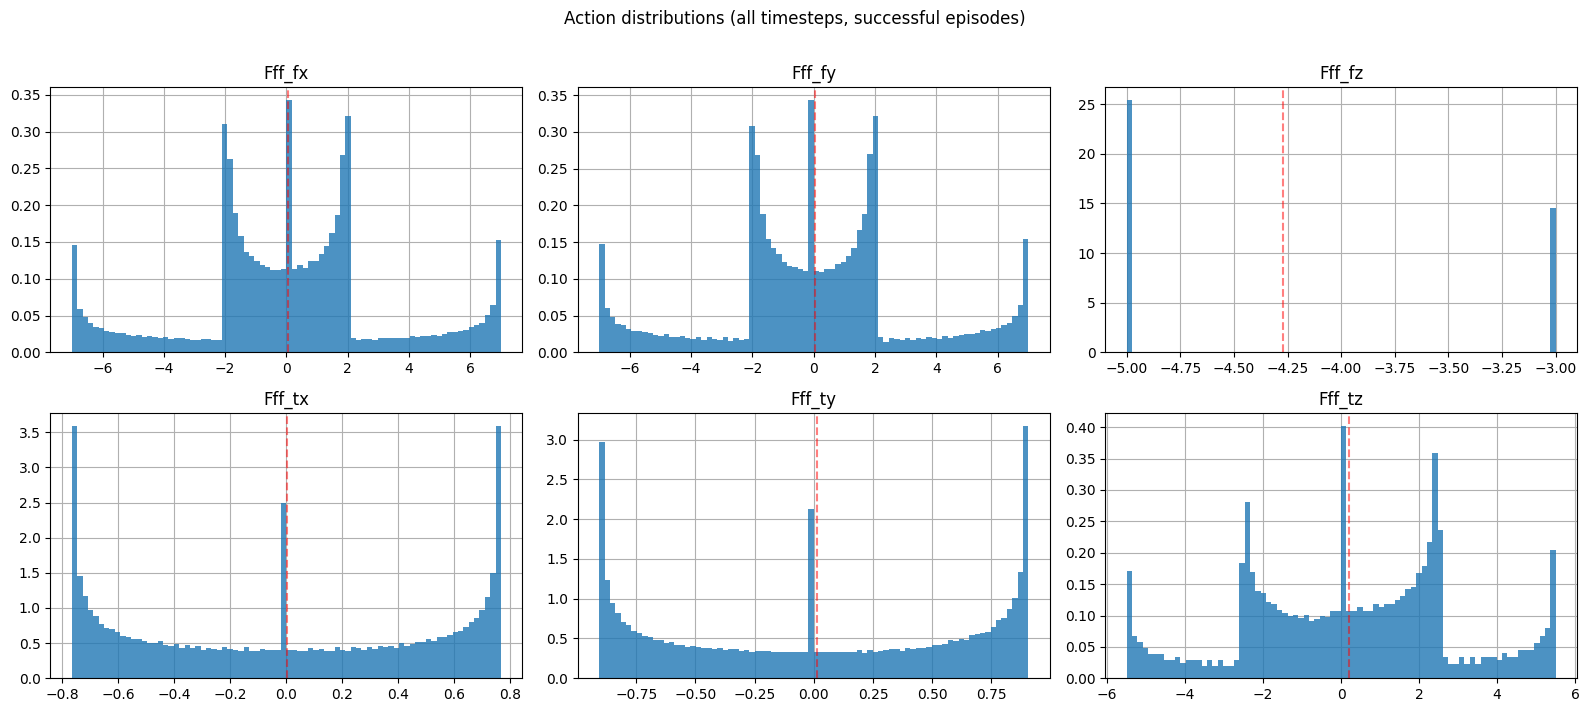

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))

for i in range(6):
    ax = axes[i // 3, i % 3]
    ax.hist(act_flat[:, i], bins=80, alpha=0.8, density=True)
    ax.set_title(act_labels[i])
    ax.axvline(act_flat[:, i].mean(), color='red', linestyle='--', alpha=0.5)

fig.suptitle('Action distributions (all timesteps, successful episodes)', y=1.01)
plt.tight_layout()

## 7. Temporal Diversity — Overlay Multiple Episodes
Plot Fff trajectories from 5 random episodes. You want to see:
- Varied search patterns (different durations, different contact sequences)
- Structurally consistent (always converges to push phase)
- If all episodes look identical, diffusion model won't learn multimodality

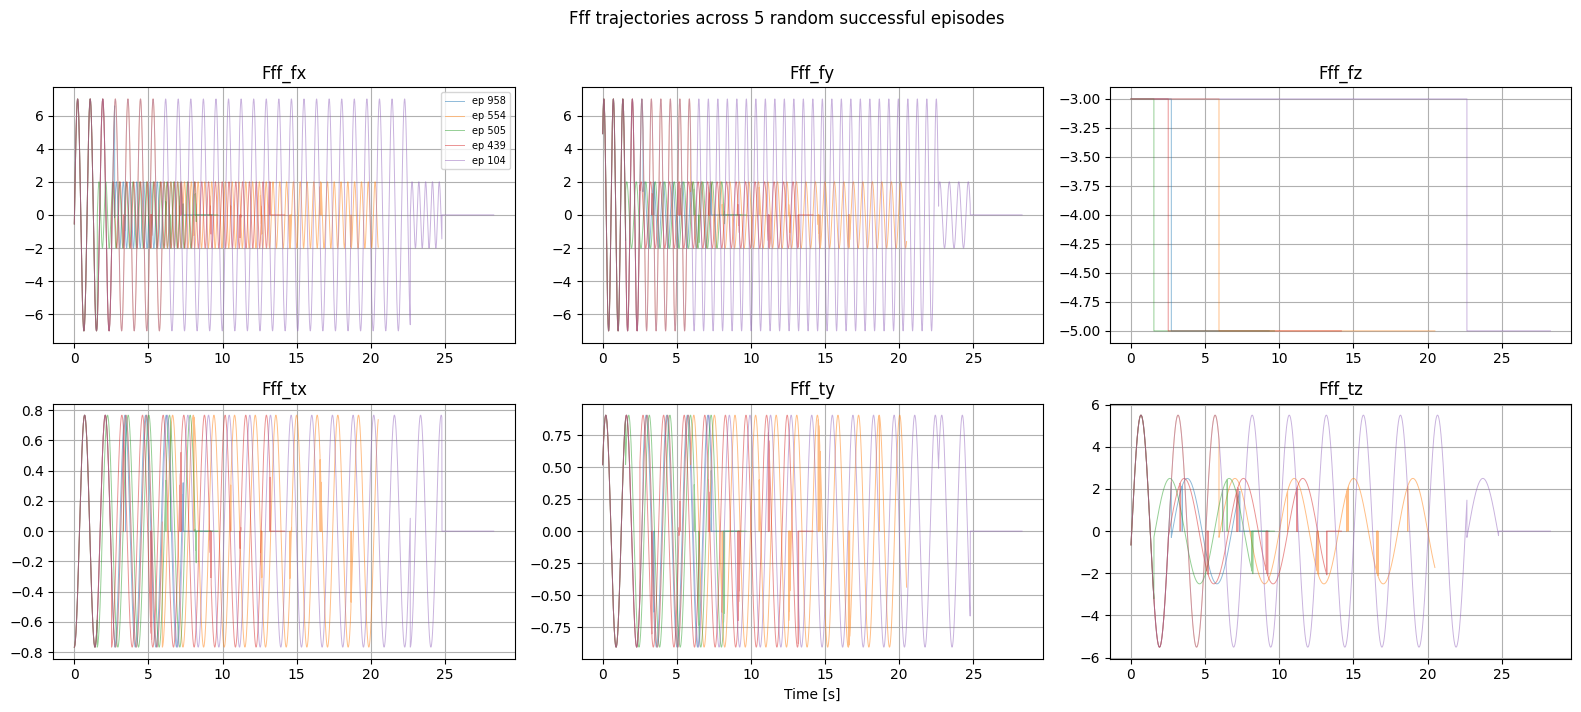

In [11]:
np.random.seed(42)
sample_indices = np.random.choice(len(successful), size=min(5, len(successful)), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))

for idx in sample_indices:
    entry = successful[idx]
    ep = load_episode(DATA_DIR / entry['path'])
    t_ep = ep['obs/timestamps'] - ep['obs/timestamps'][0]
    
    for i in range(6):
        ax = axes[i // 3, i % 3]
        ax.plot(t_ep, ep['action/Fff'][:, i], alpha=0.5, linewidth=0.7, label=f"ep {entry['episode_id']}")
        ax.set_title(act_labels[i])

axes[0, 0].legend(fontsize=7)
axes[1, 1].set_xlabel('Time [s]')
fig.suptitle('Fff trajectories across 5 random successful episodes', y=1.01)
plt.tight_layout()

## 8. Observation Channel Correlations
Correlation matrix between all obs channels. If f_ext and f_internal are nearly perfectly correlated,
one of them may be redundant (though keep both for paper fidelity).


High correlations (|r| > 0.9):


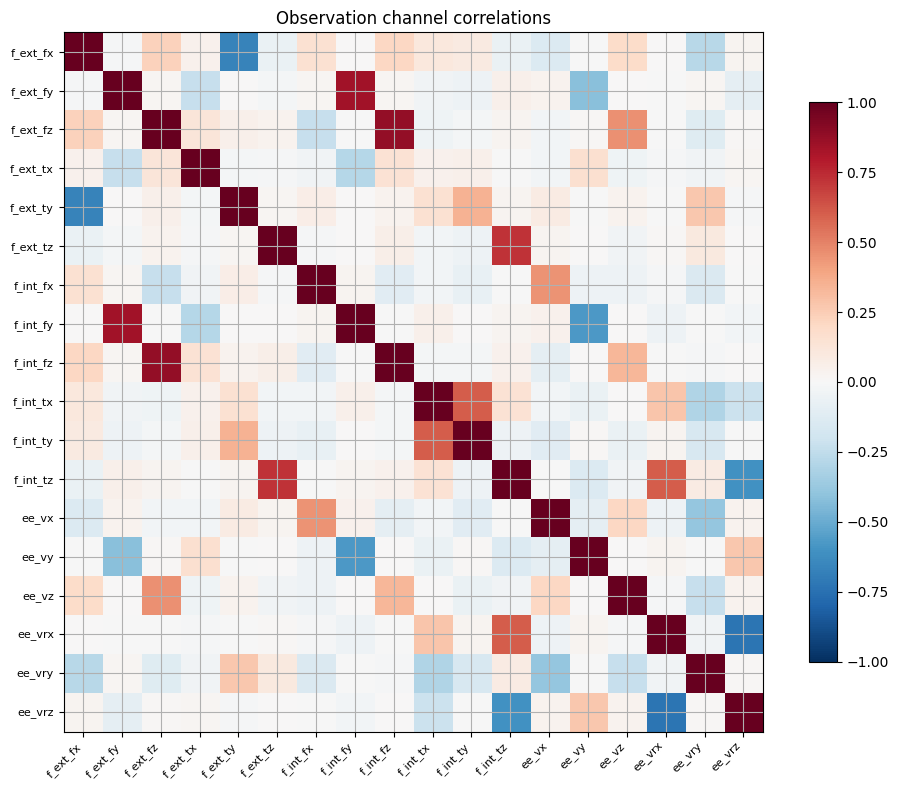

In [12]:
corr = np.corrcoef(obs_flat.T)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(n_obs_dim))
ax.set_yticks(range(n_obs_dim))
ax.set_xticklabels(obs_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(obs_labels, fontsize=8)
ax.set_title('Observation channel correlations')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

print('\nHigh correlations (|r| > 0.9):')
for i in range(n_obs_dim):
    for j in range(i+1, n_obs_dim):
        if abs(corr[i, j]) > 0.9:
            print(f'  {obs_labels[i]} ↔ {obs_labels[j]}: r={corr[i,j]:.3f}')

## 9. Outlier Detection — Episode-Level
Flag episodes whose per-channel mean or std deviates strongly from the population.
These might be borderline successes worth excluding from training.

In [13]:
ep_means = np.array([obs.mean(axis=0) for obs in all_obs])
ep_stds = np.array([obs.std(axis=0) for obs in all_obs])

pop_mean = ep_means.mean(axis=0)
pop_std = ep_means.std(axis=0)

z_threshold = 3.0
outlier_episodes = []

for i, entry in enumerate(successful):
    z_scores = np.abs((ep_means[i] - pop_mean) / (pop_std + 1e-10))
    if z_scores.max() > z_threshold:
        worst_ch = z_scores.argmax()
        outlier_episodes.append((entry['episode_id'], obs_labels[worst_ch], z_scores[worst_ch]))

if outlier_episodes:
    print(f'Potential outlier episodes (z > {z_threshold} on any channel mean):')
    for ep_id, ch, z in outlier_episodes:
        print(f'  Episode {ep_id}: worst channel = {ch}, z = {z:.1f}')
else:
    print(f'No outlier episodes found (z < {z_threshold} on all channel means)')

Potential outlier episodes (z > 3.0 on any channel mean):
  Episode 11: worst channel = f_int_tx, z = 3.1
  Episode 39: worst channel = f_int_ty, z = 3.2
  Episode 40: worst channel = ee_vrx, z = 3.8
  Episode 42: worst channel = f_ext_tx, z = 3.4
  Episode 43: worst channel = f_ext_tx, z = 4.4
  Episode 48: worst channel = f_ext_tx, z = 4.0
  Episode 58: worst channel = ee_vry, z = 3.2
  Episode 65: worst channel = f_ext_tx, z = 4.2
  Episode 68: worst channel = ee_vrz, z = 3.0
  Episode 76: worst channel = f_int_tx, z = 3.1
  Episode 81: worst channel = ee_vrx, z = 3.3
  Episode 121: worst channel = f_ext_tx, z = 4.3
  Episode 154: worst channel = ee_vry, z = 3.5
  Episode 167: worst channel = f_ext_tx, z = 3.6
  Episode 196: worst channel = ee_vrx, z = 3.2
  Episode 199: worst channel = f_ext_tx, z = 3.0
  Episode 214: worst channel = f_int_tx, z = 3.1
  Episode 236: worst channel = f_int_tx, z = 3.6
  Episode 243: worst channel = ee_vy, z = 4.4
  Episode 248: worst channel = f_ext_

## 10. Normalization Preview
Apply zero-mean / unit-variance normalization and check the result.
After normalizing, channels should be roughly centered at zero with spread ~1.


Channels with very low std (< 0.01) before normalization — may carry no useful signal:
  ee_vx: std = 0.003722
  ee_vy: std = 0.005496
  ee_vz: std = 0.006990
  ee_vrx: std = 0.009834


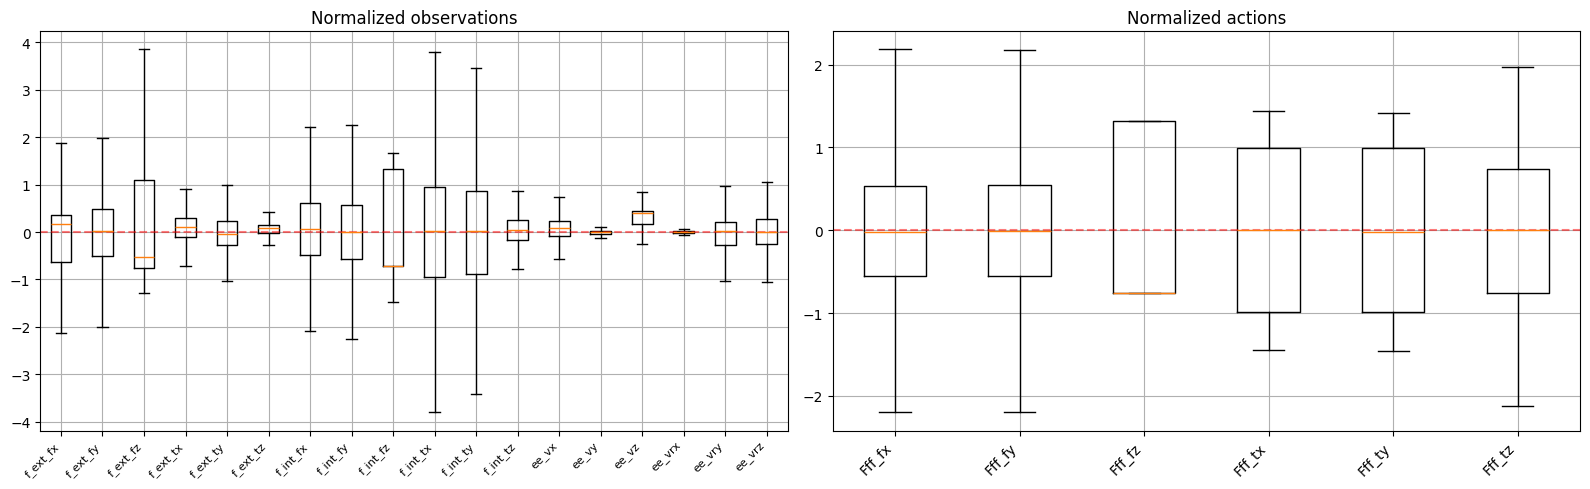

In [14]:
obs_mean = obs_flat.mean(axis=0)
obs_std_val = obs_flat.std(axis=0)
act_mean = act_flat.mean(axis=0)
act_std_val = act_flat.std(axis=0)

obs_norm = (obs_flat - obs_mean) / (obs_std_val + 1e-6)
act_norm = (act_flat - act_mean) / (act_std_val + 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].boxplot([obs_norm[:, i] for i in range(n_obs_dim)], showfliers=False)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_xticklabels(obs_labels, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Normalized observations')

axes[1].boxplot([act_norm[:, i] for i in range(6)], showfliers=False)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xticklabels(act_labels, rotation=45, ha='right')
axes[1].set_title('Normalized actions')

plt.tight_layout()

print('\nChannels with very low std (< 0.01) before normalization — may carry no useful signal:')
for i, lbl in enumerate(obs_labels):
    if obs_std_val[i] < 0.01:
        print(f'  {lbl}: std = {obs_std_val[i]:.6f}')

## 11. Summary — Training Readiness Checklist
Print a quick yes/no for each check.

In [15]:
checks = {
    'Enough successful episodes (>= 500)': len(successful) >= 500,
    'No NaN in obs': np.isnan(obs_flat).sum() == 0,
    'No NaN in actions': np.isnan(act_flat).sum() == 0,
    'No Inf in obs': np.isinf(obs_flat).sum() == 0,
    'No Inf in actions': np.isinf(act_flat).sum() == 0,
    'Obs dimensionality is 18': n_obs_dim == 18,
    'Action dimensionality is 6': act_flat.shape[1] == 6,
    'No constant obs channels': all(obs_flat[:, i].std() > 1e-8 for i in range(n_obs_dim)),
    'No constant action channels': all(act_flat[:, i].std() > 1e-8 for i in range(6)),
    'Few outlier episodes (< 5%)': len(outlier_episodes) < 0.05 * len(successful),
}

print('Training Readiness Checklist')
print('=' * 50)
all_pass = True
for check, passed in checks.items():
    status = 'PASS' if passed else 'FAIL'
    if not passed:
        all_pass = False
    print(f'  [{status}] {check}')

print('\n' + ('All checks passed — dataset is ready for training.' if all_pass 
              else 'Some checks failed — review the issues above before training.'))

Training Readiness Checklist
  [PASS] Enough successful episodes (>= 500)
  [PASS] No NaN in obs
  [PASS] No NaN in actions
  [PASS] No Inf in obs
  [PASS] No Inf in actions
  [PASS] Obs dimensionality is 18
  [PASS] Action dimensionality is 6
  [PASS] No constant obs channels
  [PASS] No constant action channels
  [FAIL] Few outlier episodes (< 5%)

Some checks failed — review the issues above before training.
